# **Upload Dataset Langsung**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Data_Sentimen_MBG.csv to Data_Sentimen_MBG.csv


# **Persiapan Library**

In [ ]:
# Install semua library yang kira-kira dibutuhkan, kalau ada yang kurang, bisa diinstall di cell selanjutnya kalau terlupakan
!pip install -q transformers datasets scikit-learn matplotlib seaborn tqdm pandas numpy tensorboard torch nltk wordcloud ipywidgets Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.4 MB/s eta 0:00:00


In [ ]:
# Import semua librarynya
import pandas as pd, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
import re, os, time
import plotly.express as px

import nltk; nltk.download('stopwords')
from nltk.corpus import stopwords
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, pipeline
from datasets import Dataset as HfDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("logs/tensorboard", exist_ok=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Device: cuda


# **Baca Dataset**

In [ ]:
# Baca file csv
df = pd.read_csv('Data_Sentimen_MBG.csv') #Disclaimer: Saya tidak memiliki maksud untuk mennyindir pihak tertentu, dataset murni untuk pengerjaan proyek saja.
print("Shape awal:", df.shape)
df.head()

Shape awal: (6419, 5)


,author,published_at,like_count,text,public
0,@Ipank049,2026-03-15T19:00:49Z,0,Penguasa dan Pelaksana Program MBG menjadi Pen...,True
1,@Tmsaja873,2026-03-15T11:15:42Z,0,anaknya makan 1x bapaknya penganguran..,True
2,@fakhrieofisial4819,2026-03-15T07:36:34Z,0,"Rusak lah negara kalau Nepotisme, korupsi sema...",True
3,@sudaryadidar1358,2026-03-14T08:23:35Z,0,Programpresiden jokowi. Berobat gratid banyak ...,True
4,@KokGiniAmat,2026-03-14T06:33:38Z,0,Maling Berkedok Gizi,True


In [ ]:
print(df["text"].sample(3).values)

['Sebelum siaran minimal mandi dulu lah..' 'hah.....😮 proyek......????'
 'Relawan tapi dibayar 😂']


# **Preprocessing Teks**

In [ ]:
normalization_dict = {
    'utk': 'untuk',
    'sdh': 'sudah',
    'tdk': 'tidak',
    'gak': 'tidak',
    'ga': 'tidak',
    'gk': 'tidak',
    'nggak': 'tidak',
    'aja': 'saja',
    'krn': 'karena',
    'dg': 'dengan',
    'dr': 'dari',
    'pd': 'pada',
    'dlm': 'dalam',
    'sy': 'saya',
    'lg': 'lagi',
    'jg': 'juga',
    'udh': 'sudah',
    'bs': 'bisa',
    'tp': 'tapi',
    'jg': 'juga',
    'kalo': 'kalau',
}

stop_words_id = set(stopwords.words('indonesian'))
stop_words_id.update(['quot', 'amp', 'nya', 'utk', 'sdh', 'dgn', 'sih'])

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text, use_stem=True):
    text = str(text).lower()

    #hapus URL
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # Hapus sisa encoding URL
    text = re.sub(r'\b[a-z]{1,3}\s[a-z]{1,3}\s[a-z]{1,3}\b', '', text)

    #hapus mention
    text = re.sub(r"@\w+", "", text)

    #hapus HTML entities dan tag
    text = text.replace('&quot;', '').replace('&amp;', '').replace('&lt;', '').replace('&gt;', '')
    text = re.sub(r"<br\s*/?>", " ", text)  # hapus tag <br>

    # Hapus karakter non-huruf
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Hapus kata-kata noise spesifik
    noise_words = {'href', 'uckszu', 'wh', 'gy', 'mb', 'dv', 'ujg', 'ksify', 'lzfolm', 'akanydqag'}

    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_id]
    tokens = [normalization_dict.get(t, t) for t in tokens]
    if use_stem:
        tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# Versi untuk GRU/LSTM (dengan stemming)
df['clean_text'] = df["text"].apply(lambda x: clean_text(x, use_stem=False))
# Versi untuk BERT (tanpa stemming)
df['bert_text'] = df["text"].apply(lambda x: re.sub(r"https?://\S+", "", str(x).lower().replace('&quot;','').replace('&amp;','')))
df = df[df['clean_text'].str.split().str.len() > 2].reset_index(drop=True)
print("Shape bersih:", df.shape)

Shape bersih: (5586, 7)


# **WordCloud & Top Kata Seluruh Data**

In [ ]:
# Gabungkan semua teks hasil preprocessing
all_text = " ".join(df['clean_text'])

# Hitung frekuensi kata
word_counts = Counter(all_text.split())

# Ambil 40 kata teratas yang bukan stopwords & panjang > 2
top_40 = [(w,c) for w,c in word_counts.most_common(100) if w not in stop_words_id and len(w)>2][:40]

# Tampilkan tabel kata teratas
print("=== 40 Kata Teratas ===")
for i,(w,c) in enumerate(top_40,1): print(f"{i:2}. {w:<20} : {c}")

=== 40 Kata Teratas ===
 1. mbg                  : 2097
 2. program              : 998
 3. rakyat               : 797
 4. proyek               : 727
 5. makan                : 644
 6. anak                 : 617
 7. tempo                : 595
 8. korupsi              : 589
 9. orang                : 559
10. negara               : 543
11. prabowo              : 518
12. gratis               : 510
13. indonesia            : 448
14. sekolah              : 393
15. uang                 : 366
16. pemerintah           : 335
17. presiden             : 291
18. dapur                : 250
19. makanan              : 248
20. pejabat              : 242
21. bergizi              : 232
22. omon                 : 204
23. politik              : 201
24. dana                 : 191
25. masyarakat           : 187
26. gizi                 : 186
27. udah                 : 181
28. bocor                : 164
29. anggaran             : 152
30. yayasan              : 148
31. pilpres              : 148
32. koruptor  

# **Visualisasi WordCloud Awal**

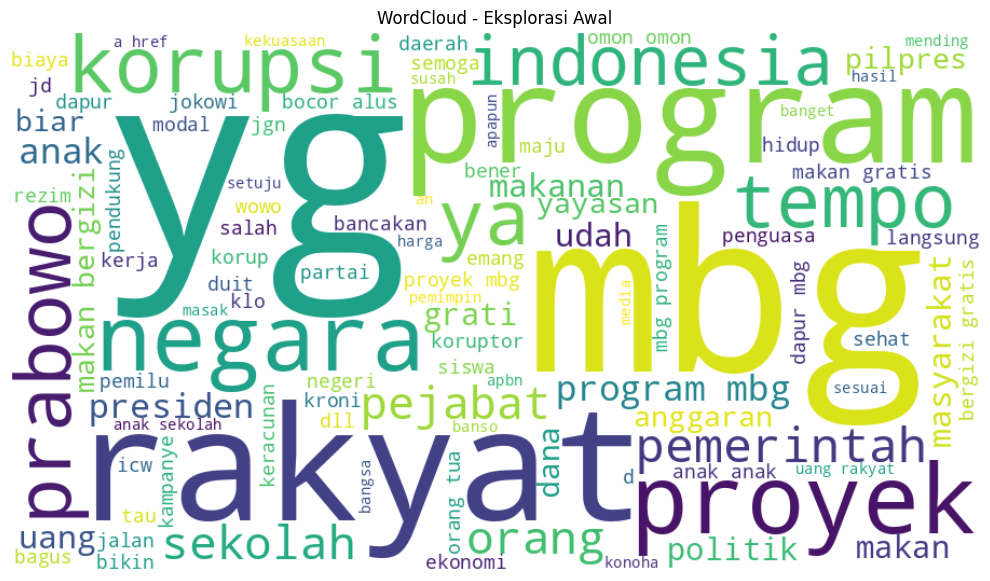

In [ ]:
# Buat WordCloud
wc_all = WordCloud(width=900, height=500, background_color='white', max_words=100, stopwords=stop_words_id).generate(all_text)
plt.figure(figsize=(14,7)); plt.imshow(wc_all, interpolation='bilinear'); plt.axis('off')
plt.title("WordCloud - Eksplorasi Awal"); plt.savefig("results/wordcloud_awal.png", dpi=150, bbox_inches='tight'); plt.show()

Analisis N-Gram

In [ ]:
def top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n,n), max_features=5000, stop_words=list(stop_words_id))
    X = vec.fit_transform(corpus)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

print("=== 15 Bigram Teratas ===")
for phrase, freq in top_ngrams(df['clean_text'], n=2):
    print(f"{phrase:<30} : {freq}")

print("\n=== 15 Trigram Teratas ===")
for phrase, freq in top_ngrams(df['clean_text'], n=3):
    print(f"{phrase:<30} : {freq}")

=== 15 Bigram Teratas ===


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.



program mbg                    : 236
makan bergizi                  : 127
makan gratis                   : 125
proyek mbg                     : 112
bocor alus                     : 112
anak anak                      : 96
mbg program                    : 92
dapur mbg                      : 90
bergizi gratis                 : 90
omon omon                      : 74
orang tua                      : 73
uang rakyat                    : 71
anak sekolah                   : 64
mbg yg                         : 55
orang orang                    : 53

=== 15 Trigram Teratas ===
makan bergizi gratis           : 74
makan siang gratis             : 33
href uckszu wh                 : 29
uckszu wh gy                   : 29
wh gy mb                       : 29
gy mb dv                       : 29
mb dv ujg                      : 29
koperasi merah putih           : 29
program makan bergizi          : 22
proyek makan gratis            : 20
proyek makan bergizi           : 18
bocor alus tempo               

N-Gram Tree

In [ ]:
def build_ngram_sunburst(corpus, max_unigrams=25, max_bigrams=15, max_trigrams=10):
    data = []
    # Root
    data.append({"id": "root", "parent": "", "label": "Semua N-Gram", "value": 1})
    data.append({"id": "unigram", "parent": "root", "label": "Unigram", "value": 1})
    data.append({"id": "bigram", "parent": "root", "label": "Bigram", "value": 1})
    data.append({"id": "trigram", "parent": "root", "label": "Trigram", "value": 1})

    # --- Unigram ---
    vec_uni = CountVectorizer(ngram_range=(1,1), max_features=5000, stop_words=list(stop_words_id))
    X_uni = vec_uni.fit_transform(corpus)
    uni_freq = X_uni.sum(axis=0).A1
    uni_words = sorted(vec_uni.vocabulary_.items(), key=lambda x: x[1])
    uni_dict = {w: uni_freq[vec_uni.vocabulary_[w]] for w, _ in uni_words}
    for w, f in sorted(uni_dict.items(), key=lambda x: x[1], reverse=True)[:max_unigrams]:
        data.append({"id": f"uni_{w}", "parent": "unigram", "label": w, "value": f})

    # --- Bigram ---
    vec_bi = CountVectorizer(ngram_range=(2,2), max_features=5000, stop_words=list(stop_words_id))
    X_bi = vec_bi.fit_transform(corpus)
    bi_freq = X_bi.sum(axis=0).A1
    bi_words = sorted(vec_bi.vocabulary_.items(), key=lambda x: x[1])
    bi_dict = {w: bi_freq[vec_bi.vocabulary_[w]] for w, _ in bi_words}
    for w, f in sorted(bi_dict.items(), key=lambda x: x[1], reverse=True)[:max_bigrams]:
        data.append({"id": f"bi_{w}", "parent": "bigram", "label": w, "value": f})

    # --- Trigram ---
    vec_tri = CountVectorizer(ngram_range=(3,3), max_features=5000, stop_words=list(stop_words_id))
    X_tri = vec_tri.fit_transform(corpus)
    tri_freq = X_tri.sum(axis=0).A1
    tri_words = sorted(vec_tri.vocabulary_.items(), key=lambda x: x[1])
    tri_dict = {w: tri_freq[vec_tri.vocabulary_[w]] for w, _ in tri_words}
    for w, f in sorted(tri_dict.items(), key=lambda x: x[1], reverse=True)[:max_trigrams]:
        data.append({"id": f"tri_{w}", "parent": "trigram", "label": w, "value": f})

    return pd.DataFrame(data)

# Jalankan
df_sunburst = build_ngram_sunburst(df['clean_text'], max_unigrams=25, max_bigrams=15, max_trigrams=10)

fig = px.sunburst(
    df_sunburst,
    ids='id',
    parents='parent',
    values='value',
    title='Hierarki N-Gram (Unigram → Bigram → Trigram)',
    color='value',
    color_continuous_scale='Viridis',
    maxdepth=3
)
fig.update_traces(textinfo='label+percent entry')
fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.



# **Definisikan Lexicon**

In [ ]:
negative_words = {
    'korupsi','korup','koruptor','bubarkan','hancur','parah','sengsara','bangsat','edan','jijik','mampus','busuk','basi',
    'gagal','bohong','tipu','akal-akalan','penderitaan','rezim','penguasa','oligarki','markus','bancakan','bagi-bagi','kroni',
    'cawe','proyek','dapur','pencitraan','bencana','rugi','tolol','bodoh','bego','gila','sampah',
    'bocor','bocor alus','omon','omon omon','uang rakyat','proyek mbg','dapur mbg',
    'koruptor','pilpres','yayasan','mbg proyek','hentikan','stop','musnahkan',
}

positive_words = {
    'terima kasih','bagus','sehat','manfaat','membantu','sukses','lanjutkan','setuju','dukung','hebat','pintar','cerdas',
    'sejahtera','makmur','gratis','berkualitas','baik','peduli','bangga','harapan','yakin','percaya','patriotik','jaya',
    'berhasil','mantap','luar biasa','keren','top','kagum',
    'makan bergizi gratis','makan bergizi','bergizi gratis','makan siang gratis','program makan bergizi',
}

def lexicon_label(text):
    text_lower = text.lower()
    for w in negative_words:
        if w in text_lower: return 2
    for w in positive_words:
        if w in text_lower: return 1
    return None

# **Auto‑Labeling Sentimen dengan mdhugol/indonesia-ber**

In [ ]:
classifier = pipeline(
    "sentiment-analysis",
    model="mdhugol/indonesia-bert-sentiment-classification",
    return_all_scores=True
)
label_map = {'LABEL_0': 2, 'LABEL_1': 0, 'LABEL_2': 1}

def auto_label_and_confidence(text):
    try:
        scores = classifier(text[:512])[0]
        top = max(scores, key=lambda x: x['score'])
        return label_map[top['label']], top['score']
    except:
        return 0, 0.0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# **Combined Labeling**

In [ ]:
def combined_label(text):
    lex = lexicon_label(text)
    if lex is not None:
        return lex, 1.0  # confidence penuh
    else:
        return auto_label_and_confidence(text)

# Jalankan labeling
results = df['clean_text'].apply(combined_label)
df['label'] = results.apply(lambda x: x[0])
df['confidence'] = results.apply(lambda x: x[1])

print("Distribusi label (setelah lexicon + auto-label):")
print(df['label'].value_counts())
print("Rata-rata confidence:", df['confidence'].mean())

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Distribusi label (setelah lexicon + auto-label):
label
2    2473
0    2274
1     839
Name: count, dtype: int64
Rata-rata confidence: 0.5929108485499462


# **WordCloud per Kelas**

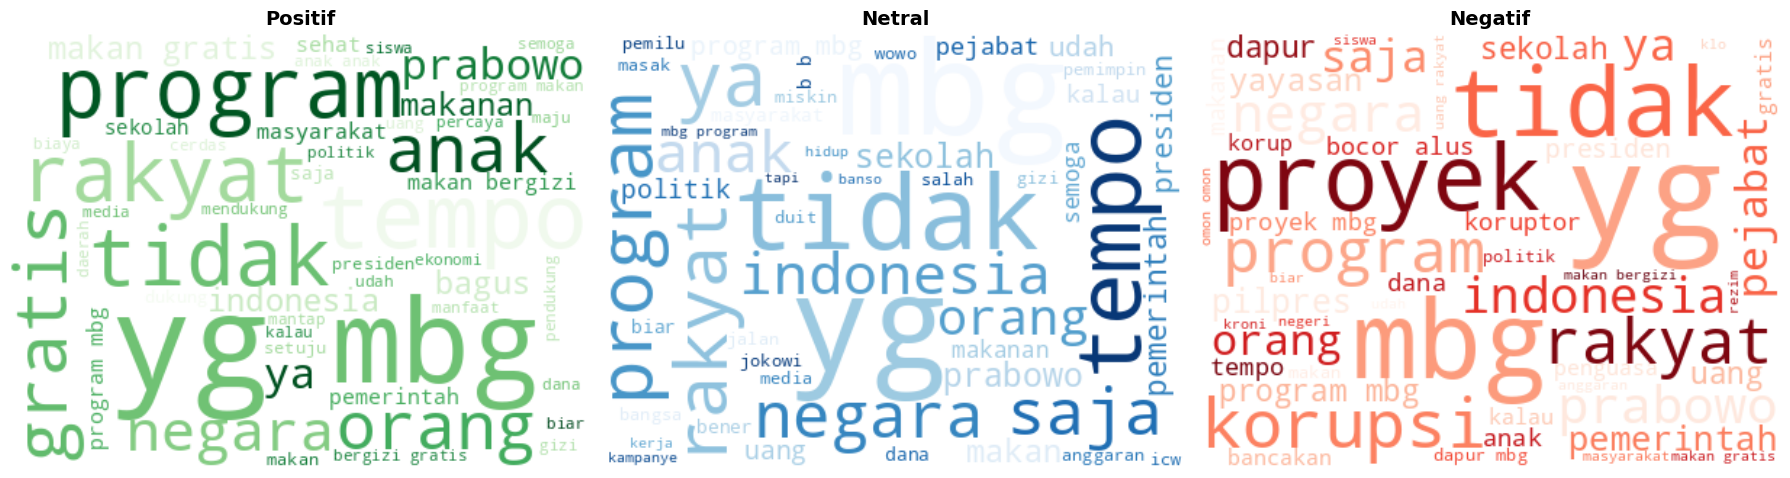

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(18,6))
for ax, lbl, title, cmap in zip(axes, [1,0,2], ['Positif','Netral','Negatif'], ['Greens','Blues','Reds']):
    text = " ".join(df[df['label']==lbl]['clean_text'])
    wc = WordCloud(width=400, height=300, background_color='white', colormap=cmap, max_words=50).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.set_title(title, fontsize=14, fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.savefig("results/wordcloud_per_kelas.png", dpi=150); plt.show()

# **Visualisasi Distribusi**

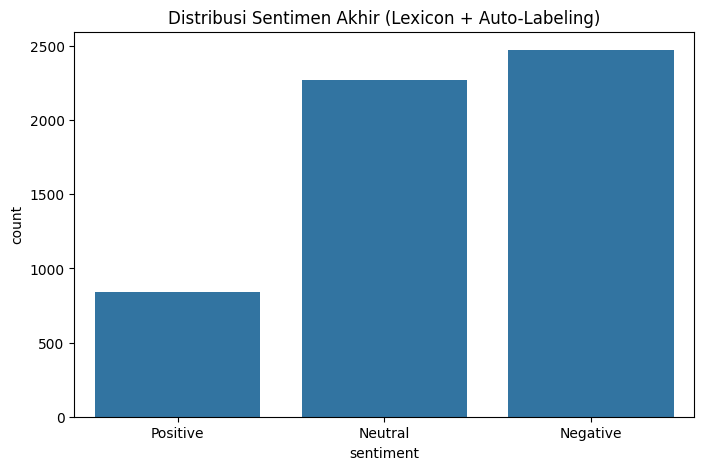

In [ ]:
class_names = {0: "Neutral", 1: "Positive", 2: "Negative"}
df['sentiment'] = df['label'].map(class_names)

plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, order=['Positive','Neutral','Negative'])
plt.title("Distribusi Sentimen Akhir (Lexicon + Auto-Labeling)")
plt.savefig("results/sentiment_distribution.png")
plt.show()

# **Siapkan Data (Tokenisasi & Padding)**

In [ ]:
def build_vocab(texts, max_vocab=15000):
    counter = Counter()
    for t in texts: counter.update(t.split())
    vocab = {'<PAD>':0, '<UNK>':1}
    for w, _ in counter.most_common(max_vocab):
        vocab[w] = len(vocab)
    return vocab

vocab = build_vocab(df['clean_text'], max_vocab=15000)
vocab_size = len(vocab)
max_len = 60

def encode_text(text):
    ids = [vocab.get(t, 1) for t in text.split()[:max_len]]
    return ids + [0]*(max_len - len(ids))

df['encoded'] = df['clean_text'].apply(encode_text)

X = np.array(df['encoded'].tolist())
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4468, 60) Test: (1118, 60)


# **DataLoader**

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=batch_size)

# **Model LSTM + Attention**

In [ ]:
class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=200, hidden_dim=256, output_dim=3, dropout=0.3, use_attention=True):
        super().__init__()
        self.use_attention = use_attention
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        if use_attention:
            self.attention = nn.Linear(hidden_dim*2, 1)
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(x)
        if self.use_attention:
            attn = torch.softmax(self.attention(outputs).squeeze(-1), dim=1)
            context = torch.sum(outputs * attn.unsqueeze(-1), dim=1)
        else:
            context = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(context))

# Model dengan Attention
model_lstm_att = AttentionLSTM(len(vocab), use_attention=True).to(device)
print(model_lstm_att)

# Model tanpa Attention
model_lstm_noatt = AttentionLSTM(len(vocab), use_attention=False).to(device)
print(model_lstm_noatt)

AttentionLSTM(
  (embedding): Embedding(12462, 200, padding_idx=0)
  (lstm): LSTM(200, 256, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
AttentionLSTM(
  (embedding): Embedding(12462, 200, padding_idx=0)
  (lstm): LSTM(200, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


# **Model GRU + Attention**

In [ ]:
class AttentionGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=200, hidden_dim=256, output_dim=3, dropout=0.3, use_attention=True):
        super().__init__()
        self.use_attention = use_attention
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        if use_attention:
            self.attention = nn.Linear(hidden_dim*2, 1)
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        outputs, hidden = self.gru(x)
        if self.use_attention:
            attn = torch.softmax(self.attention(outputs).squeeze(-1), dim=1)
            context = torch.sum(outputs * attn.unsqueeze(-1), dim=1)
        else:
            context = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(context))

# Model dengan Attention
model_gru_att = AttentionGRU(len(vocab), use_attention=True).to(device)
print(model_gru_att)

# Model tanpa Attention
model_gru_noatt = AttentionGRU(len(vocab), use_attention=False).to(device)
print(model_gru_noatt)

AttentionGRU(
  (embedding): Embedding(12462, 200, padding_idx=0)
  (gru): GRU(200, 256, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
AttentionGRU(
  (embedding): Embedding(12462, 200, padding_idx=0)
  (gru): GRU(200, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


# **Training & Evaluation Function untuk LSTM dan GRU**

In [ ]:
def train_rnn(model, train_loader, test_loader, y_train, epochs=15, lr=0.0005, log_dir="logs/rnn", model_path="model.pt"):
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    writer = SummaryWriter(log_dir=log_dir)
    best_acc = 0.0; history = {'train_loss':[],'val_acc':[],'val_f1':[]}
    start = time.time()
    for epoch in range(epochs):
        model.train(); total_loss = 0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(); loss = criterion(model(inputs), labels); loss.backward(); optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        writer.add_scalar("Loss/train", avg_loss, epoch)
        model.eval(); preds, truths = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device); outputs = model(inputs)
                preds.extend(outputs.argmax(1).cpu().numpy()); truths.extend(labels.numpy())
        acc = accuracy_score(truths, preds); f1 = f1_score(truths, preds, average='weighted')
        writer.add_scalar("Accuracy/val", acc, epoch); writer.add_scalar("F1/val", f1, epoch)
        history['train_loss'].append(avg_loss); history['val_acc'].append(acc); history['val_f1'].append(f1)
        print(f"Epoch {epoch+1}: Loss {avg_loss:.4f} | Acc {acc:.4f} | F1 {f1:.4f}")
        if acc > best_acc:
            best_acc = acc; torch.save(model.state_dict(), model_path); print("  -> saved best")
    writer.close()
    return history, time.time() - start

def evaluate_rnn(model, test_loader, name):
    model.load_state_dict(torch.load(f"models/{name}.pt")); model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for inputs, lbls in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds.extend(outputs.argmax(1).cpu().numpy()); labels.extend(lbls.numpy())
    acc = accuracy_score(labels, preds); prec = precision_score(labels, preds, average='weighted')
    rec = recall_score(labels, preds, average='weighted'); f1 = f1_score(labels, preds, average='weighted')
    print(f"\n=== {name.upper()} ===")
    print(f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    print(classification_report(labels, preds, target_names=['Neutral','Positive','Negative']))
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neutral','Positive','Negative'], yticklabels=['Neutral','Positive','Negative'])
    plt.title(f"{name} Confusion Matrix"); plt.savefig(f"results/cm_{name}.png"); plt.show()
    return acc, prec, rec, f1, labels, preds

# **Training LSTM dan GRU**

In [ ]:
print("=== TRAINING MODEL UTAMA ===")
hist_lstm_att, t_lstm_att = train_rnn(model_lstm_att, train_loader, test_loader, y_train, epochs=15, log_dir="logs/lstm_att", model_path="models/lstm_att.pt")
hist_gru_att, t_gru_att = train_rnn(model_gru_att, train_loader, test_loader, y_train, epochs=15, log_dir="logs/gru_att", model_path="models/gru_att.pt")

print("\n=== ABLASI: TANPA ATTENTION ===")
hist_lstm_no, t_lstm_no = train_rnn(model_lstm_noatt, train_loader, test_loader, y_train, epochs=15, log_dir="logs/lstm_noatt", model_path="models/lstm_noatt.pt")
hist_gru_no, t_gru_no = train_rnn(model_gru_noatt, train_loader, test_loader, y_train, epochs=15, log_dir="logs/gru_noatt", model_path="models/gru_noatt.pt")

=== TRAINING MODEL UTAMA ===


Epoch 1: 100%|██████████| 70/70 [00:01<00:00, 46.85it/s]


Epoch 1: Loss 0.9826 | Acc 0.7129 | F1 0.7217
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 75.01it/s]


Epoch 2: Loss 0.6091 | Acc 0.7737 | F1 0.7833
  -> saved best


...

Epoch 13: Loss 0.0107 | Acc 0.8524 | F1 0.8523


Epoch 14: 100%|██████████| 70/70 [00:00<00:00, 106.65it/s]


Epoch 14: Loss 0.0075 | Acc 0.8649 | F1 0.8641
  -> saved best


Epoch 15: 100%|██████████| 70/70 [00:00<00:00, 106.08it/s]


Epoch 15: Loss 0.0060 | Acc 0.8640 | F1 0.8632


# **Cross-Validation LSTM dan GRU**


--- LSTM Fold 1 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 72.22it/s]


Epoch 1: Loss 0.9512 | Acc 0.7039 | F1 0.7105
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 79.99it/s]


Epoch 2: Loss 0.6118 | Acc 0.7862 | F1 0.7911
  -> saved best


...

Epoch 6: Loss 0.0848 | Acc 0.8676 | F1 0.8678
  -> saved best


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 79.34it/s]


Epoch 7: Loss 0.0543 | Acc 0.8623 | F1 0.8615


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 78.15it/s]


Epoch 8: Loss 0.0261 | Acc 0.8497 | F1 0.8504

=== FOLD_LSTM_0 ===
Acc: 0.8676 | Prec: 0.8687 | Rec: 0.8676 | F1: 0.8678
              precision    recall  f1-score   support

     Neutral       0.86      0.90      0.88       455
    Positive       0.73      0.73      0.73       168
    Negative       0.93      0.89      0.91       495

    accuracy                           0.87      1118
   macro avg       0.84      0.84      0.84      1118
weighted avg       0.87      0.87      0.87      1118



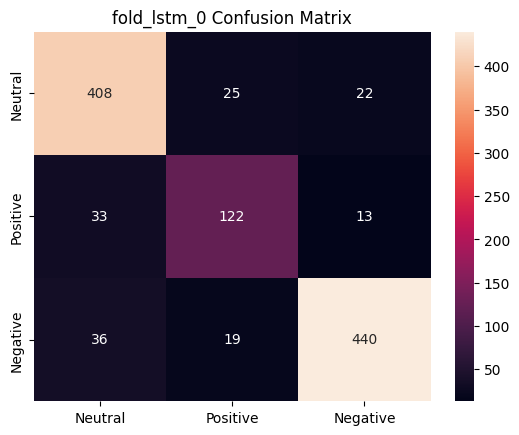


--- LSTM Fold 2 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 74.91it/s]


Epoch 1: Loss 0.9683 | Acc 0.6992 | F1 0.7019
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 78.58it/s]


Epoch 2: Loss 0.5963 | Acc 0.7986 | F1 0.7991
  -> saved best


...

Epoch 6: Loss 0.0903 | Acc 0.8469 | F1 0.8471


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 77.31it/s]


Epoch 7: Loss 0.0412 | Acc 0.8612 | F1 0.8605
  -> saved best


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 77.61it/s]


Epoch 8: Loss 0.0194 | Acc 0.8523 | F1 0.8512

=== FOLD_LSTM_1 ===
Acc: 0.8612 | Prec: 0.8641 | Rec: 0.8612 | F1: 0.8605
              precision    recall  f1-score   support

     Neutral       0.81      0.91      0.86       455
    Positive       0.80      0.68      0.74       167
    Negative       0.93      0.88      0.90       495

    accuracy                           0.86      1117
   macro avg       0.85      0.82      0.83      1117
weighted avg       0.86      0.86      0.86      1117



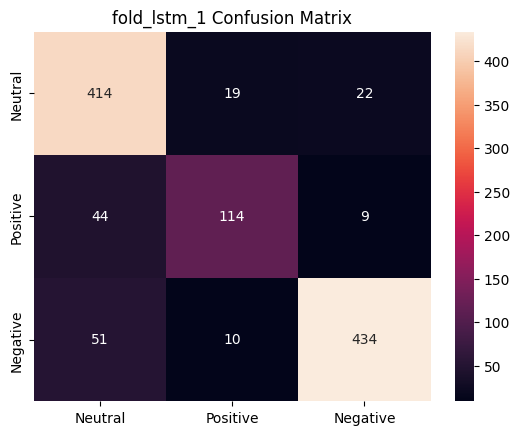


--- LSTM Fold 3 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 77.65it/s]


Epoch 1: Loss 0.9462 | Acc 0.6491 | F1 0.6663
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 77.61it/s]


Epoch 2: Loss 0.5699 | Acc 0.7628 | F1 0.7696
  -> saved best


...

Epoch 6: Loss 0.0776 | Acc 0.8380 | F1 0.8381
  -> saved best


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 76.59it/s]


Epoch 7: Loss 0.0389 | Acc 0.8326 | F1 0.8319


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 76.36it/s]


Epoch 8: Loss 0.0257 | Acc 0.8317 | F1 0.8324

=== FOLD_LSTM_2 ===
Acc: 0.8380 | Prec: 0.8390 | Rec: 0.8380 | F1: 0.8381
              precision    recall  f1-score   support

     Neutral       0.83      0.87      0.85       454
    Positive       0.68      0.67      0.68       168
    Negative       0.90      0.87      0.88       495

    accuracy                           0.84      1117
   macro avg       0.80      0.80      0.80      1117
weighted avg       0.84      0.84      0.84      1117



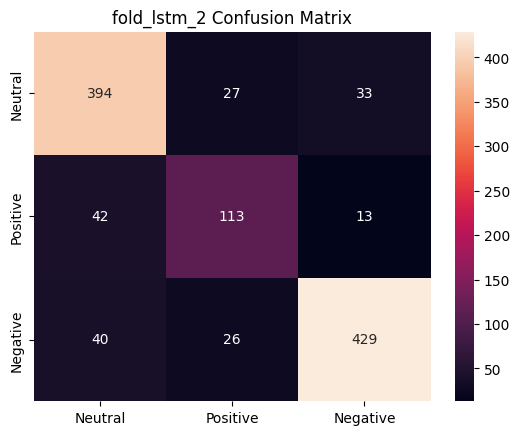


--- LSTM Fold 4 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 75.75it/s]


Epoch 1: Loss 0.9460 | Acc 0.7037 | F1 0.7083
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 75.98it/s]


Epoch 2: Loss 0.5830 | Acc 0.7816 | F1 0.7843
  -> saved best


...

Epoch 6: Loss 0.1045 | Acc 0.8415 | F1 0.8442
  -> saved best


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 74.74it/s]


Epoch 7: Loss 0.0499 | Acc 0.8362 | F1 0.8399


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 74.10it/s]


Epoch 8: Loss 0.0277 | Acc 0.8317 | F1 0.8332

=== FOLD_LSTM_3 ===
Acc: 0.8415 | Prec: 0.8491 | Rec: 0.8415 | F1: 0.8442
              precision    recall  f1-score   support

     Neutral       0.88      0.83      0.85       455
    Positive       0.63      0.75      0.68       168
    Negative       0.90      0.89      0.89       494

    accuracy                           0.84      1117
   macro avg       0.80      0.82      0.81      1117
weighted avg       0.85      0.84      0.84      1117



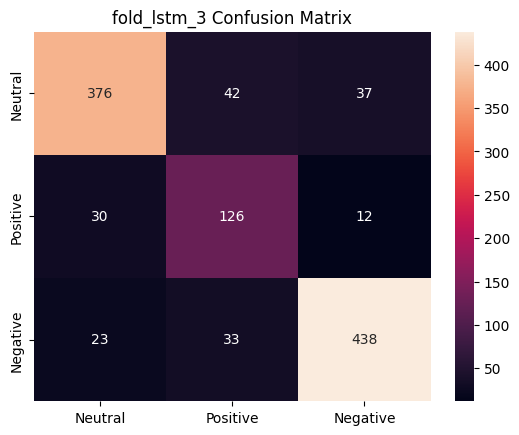


--- LSTM Fold 5 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 74.29it/s]


Epoch 1: Loss 0.9577 | Acc 0.6974 | F1 0.7052
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 75.01it/s]


Epoch 2: Loss 0.5959 | Acc 0.7735 | F1 0.7832
  -> saved best


...

Epoch 6: Loss 0.0841 | Acc 0.8362 | F1 0.8404


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 74.32it/s]


Epoch 7: Loss 0.0553 | Acc 0.8532 | F1 0.8536


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 74.87it/s]


Epoch 8: Loss 0.0314 | Acc 0.8505 | F1 0.8508

=== FOLD_LSTM_4 ===
Acc: 0.8559 | Prec: 0.8601 | Rec: 0.8559 | F1: 0.8572
              precision    recall  f1-score   support

     Neutral       0.84      0.88      0.86       455
    Positive       0.71      0.77      0.74       168
    Negative       0.93      0.86      0.89       494

    accuracy                           0.86      1117
   macro avg       0.83      0.84      0.83      1117
weighted avg       0.86      0.86      0.86      1117



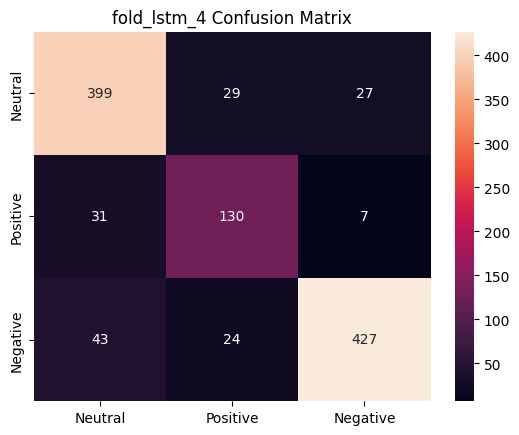


Cross‑Val LSTM: Acc = 0.8528 ± 0.0114, F1  = 0.8562 ± 0.0108

--- GRU Fold 1 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 96.29it/s]


Epoch 1: Loss 0.9292 | Acc 0.6601 | F1 0.6763
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 93.81it/s]


Epoch 2: Loss 0.6142 | Acc 0.7818 | F1 0.7863
  -> saved best


...

Epoch 6: Loss 0.0683 | Acc 0.8470 | F1 0.8476


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 96.80it/s]


Epoch 7: Loss 0.0413 | Acc 0.8515 | F1 0.8505


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 97.15it/s]


Epoch 8: Loss 0.0192 | Acc 0.8596 | F1 0.8592
  -> saved best

=== FOLD_GRU_0 ===
Acc: 0.8596 | Prec: 0.8591 | Rec: 0.8596 | F1: 0.8592
              precision    recall  f1-score   support

     Neutral       0.87      0.85      0.86       455
    Positive       0.74      0.73      0.74       168
    Negative       0.89      0.92      0.90       495

    accuracy                           0.86      1118
   macro avg       0.83      0.83      0.83      1118
weighted avg       0.86      0.86      0.86      1118



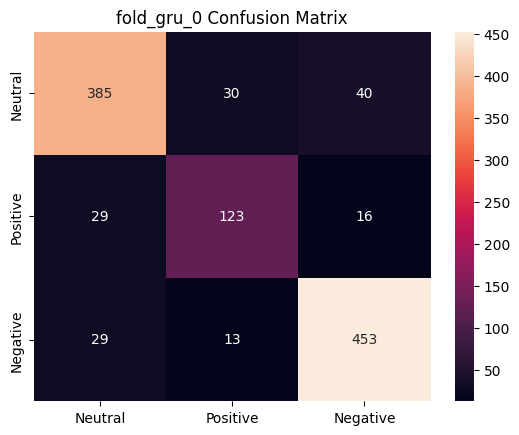


--- GRU Fold 2 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 97.70it/s]


Epoch 1: Loss 0.9126 | Acc 0.7090 | F1 0.7048
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 97.72it/s]


Epoch 2: Loss 0.5839 | Acc 0.7726 | F1 0.7802
  -> saved best


...

Epoch 6: Loss 0.0712 | Acc 0.8514 | F1 0.8510
  -> saved best


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 95.01it/s]


Epoch 7: Loss 0.0386 | Acc 0.8469 | F1 0.8466


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 98.45it/s]


Epoch 8: Loss 0.0273 | Acc 0.8389 | F1 0.8394

=== FOLD_GRU_1 ===
Acc: 0.8514 | Prec: 0.8510 | Rec: 0.8514 | F1: 0.8510
              precision    recall  f1-score   support

     Neutral       0.84      0.86      0.85       455
    Positive       0.72      0.69      0.71       167
    Negative       0.91      0.90      0.90       495

    accuracy                           0.85      1117
   macro avg       0.82      0.82      0.82      1117
weighted avg       0.85      0.85      0.85      1117



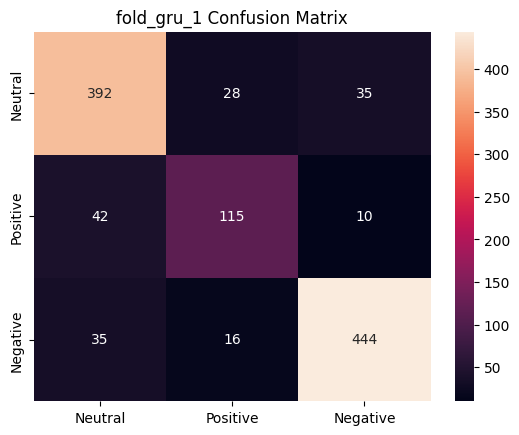


--- GRU Fold 3 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 95.39it/s]


Epoch 1: Loss 0.8982 | Acc 0.6795 | F1 0.6897
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 94.07it/s]


Epoch 2: Loss 0.5633 | Acc 0.7708 | F1 0.7784
  -> saved best


...

Epoch 6: Loss 0.0683 | Acc 0.8478 | F1 0.8471
  -> saved best


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 99.17it/s]


Epoch 7: Loss 0.0350 | Acc 0.8451 | F1 0.8449


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 99.97it/s]


Epoch 8: Loss 0.0148 | Acc 0.8469 | F1 0.8472

=== FOLD_GRU_2 ===
Acc: 0.8478 | Prec: 0.8470 | Rec: 0.8478 | F1: 0.8471
              precision    recall  f1-score   support

     Neutral       0.83      0.87      0.85       454
    Positive       0.72      0.67      0.70       168
    Negative       0.90      0.89      0.89       495

    accuracy                           0.85      1117
   macro avg       0.82      0.81      0.81      1117
weighted avg       0.85      0.85      0.85      1117



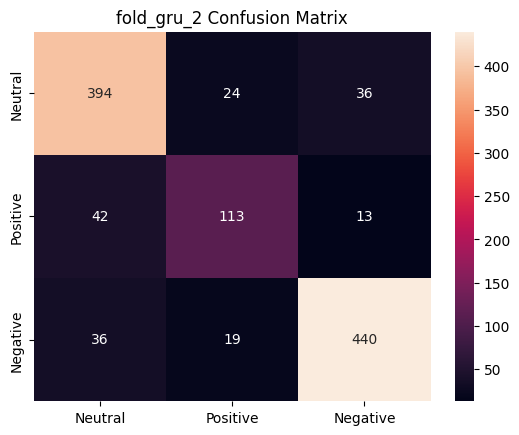


--- GRU Fold 4 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 99.77it/s]


Epoch 1: Loss 0.9013 | Acc 0.6813 | F1 0.6918
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 99.45it/s]


Epoch 2: Loss 0.5685 | Acc 0.8111 | F1 0.8163
  -> saved best


...

Epoch 6: Loss 0.0585 | Acc 0.8747 | F1 0.8749
  -> saved best


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 98.45it/s]


Epoch 7: Loss 0.0384 | Acc 0.8594 | F1 0.8597


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 94.03it/s]


Epoch 8: Loss 0.0181 | Acc 0.8621 | F1 0.8615

=== FOLD_GRU_3 ===
Acc: 0.8747 | Prec: 0.8762 | Rec: 0.8747 | F1: 0.8749
              precision    recall  f1-score   support

     Neutral       0.87      0.91      0.89       455
    Positive       0.75      0.76      0.76       168
    Negative       0.93      0.88      0.90       494

    accuracy                           0.87      1117
   macro avg       0.85      0.85      0.85      1117
weighted avg       0.88      0.87      0.87      1117



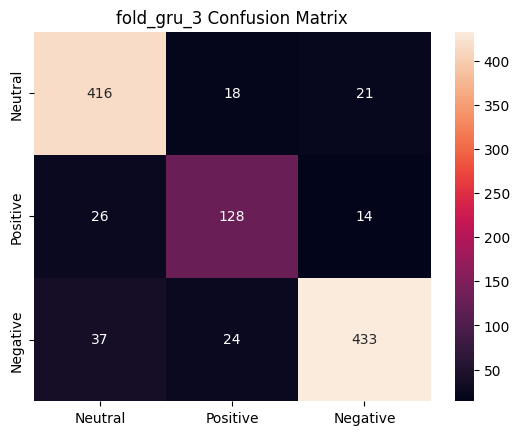


--- GRU Fold 5 ---


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 94.58it/s]


Epoch 1: Loss 0.8946 | Acc 0.6929 | F1 0.7032
  -> saved best


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 93.71it/s]


Epoch 2: Loss 0.5636 | Acc 0.7977 | F1 0.7995
  -> saved best


...

Epoch 6: Loss 0.0664 | Acc 0.8424 | F1 0.8441


Epoch 7: 100%|██████████| 70/70 [00:00<00:00, 100.51it/s]


Epoch 7: Loss 0.0374 | Acc 0.8344 | F1 0.8348


Epoch 8: 100%|██████████| 70/70 [00:00<00:00, 100.23it/s]


Epoch 8: Loss 0.0184 | Acc 0.8451 | F1 0.8457

=== FOLD_GRU_4 ===
Acc: 0.8469 | Prec: 0.8517 | Rec: 0.8469 | F1: 0.8486
              precision    recall  f1-score   support

     Neutral       0.85      0.85      0.85       455
    Positive       0.68      0.77      0.72       168
    Negative       0.91      0.87      0.89       494

    accuracy                           0.85      1117
   macro avg       0.81      0.83      0.82      1117
weighted avg       0.85      0.85      0.85      1117



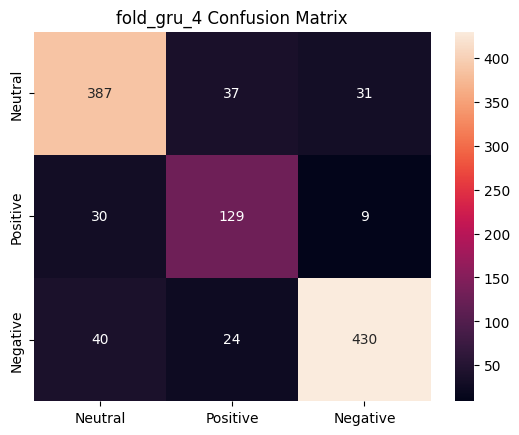


Cross‑Val GRU: Acc = 0.8561 ± 0.0103, F1  = 0.8570 ± 0.0104


In [ ]:
def cross_val_rnn(model_class, X, y, vocab_size, model_name, epochs=10, n_splits=5):
    """
    model_name : str, contoh 'lstm' atau 'gru', untuk membedakan log & model
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_acc, fold_f1 = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- {model_name.upper()} Fold {fold+1} ---")
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        tr_loader = DataLoader(SentimentDataset(X_tr, y_tr), batch_size=64, shuffle=True)
        val_loader = DataLoader(SentimentDataset(X_val, y_val), batch_size=64)

        # Model baru setiap fold
        model = model_class(vocab_size, use_attention=True).to(device)

        # Folder & nama file per model per fold
        log_dir = f"logs/fold_{model_name}_{fold}"
        model_path = f"models/fold_{model_name}_{fold}.pt"

        hist, _ = train_rnn(model, tr_loader, val_loader, y_tr,
                            epochs=epochs, log_dir=log_dir, model_path=model_path)
        acc, f1, _, _, _, _ = evaluate_rnn(model, val_loader, f"fold_{model_name}_{fold}")

        fold_acc.append(acc)
        fold_f1.append(f1)

    print(f"\nCross‑Val {model_name.upper()}: "
          f"Acc = {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}, "
          f"F1  = {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
    return fold_acc, fold_f1

# Jalankan untuk LSTM dan GRU
cv_acc_lstm, cv_f1_lstm = cross_val_rnn(AttentionLSTM, X, y, len(vocab), model_name="lstm", epochs=8, n_splits=5)
cv_acc_gru,  cv_f1_gru  = cross_val_rnn(AttentionGRU,  X, y, len(vocab), model_name="gru",  epochs=8, n_splits=5)

# **Learning Curve**

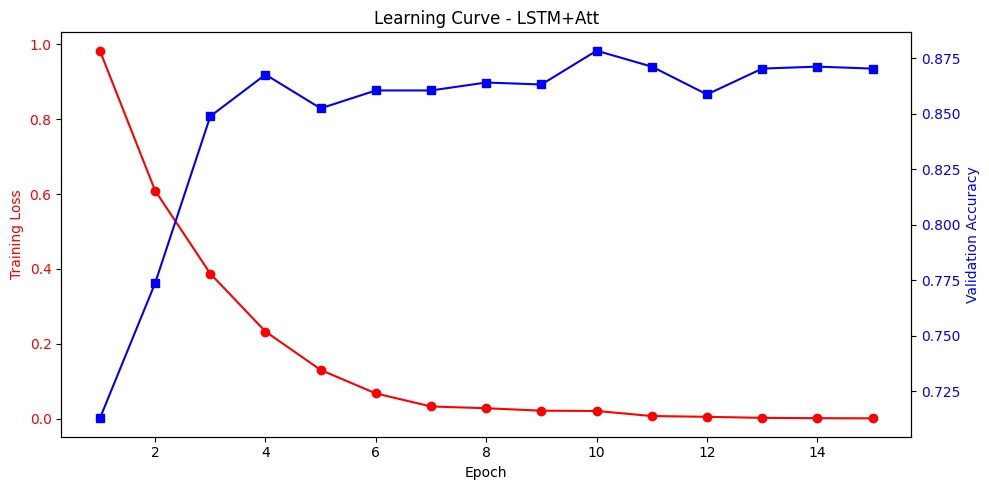

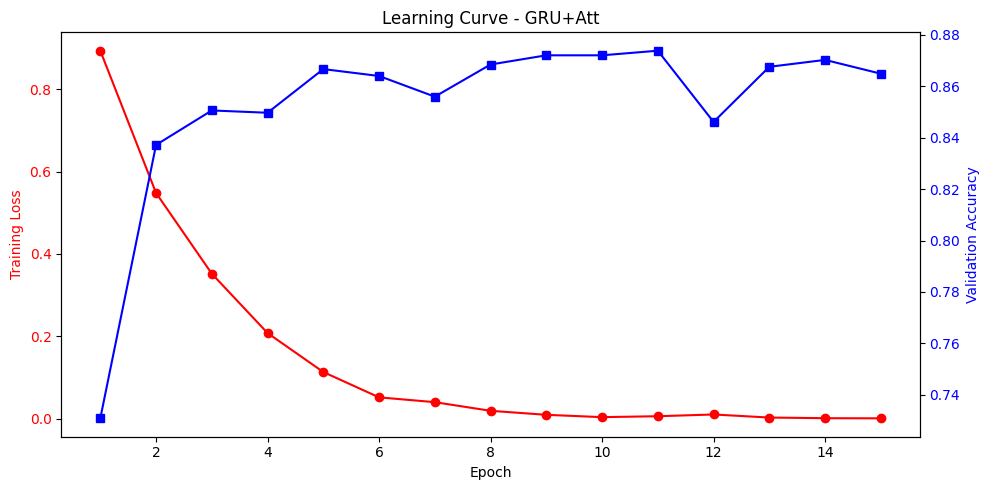

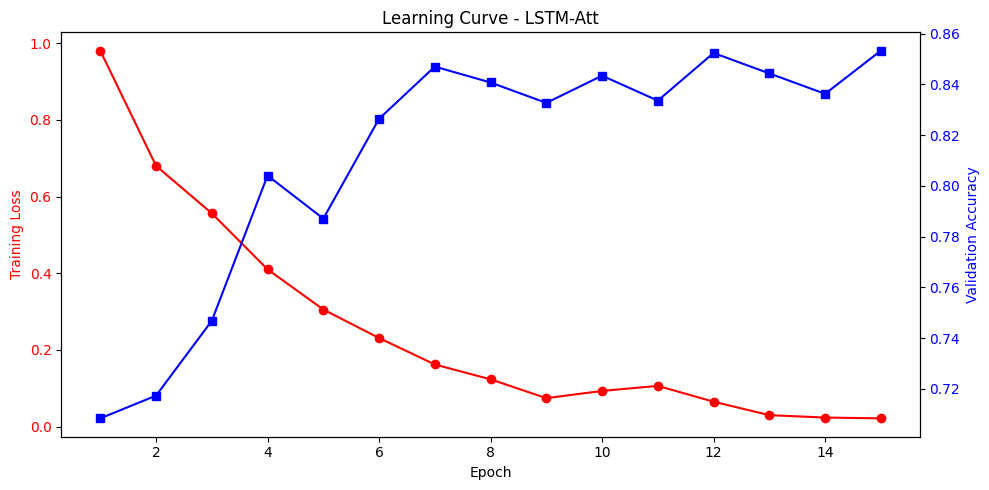

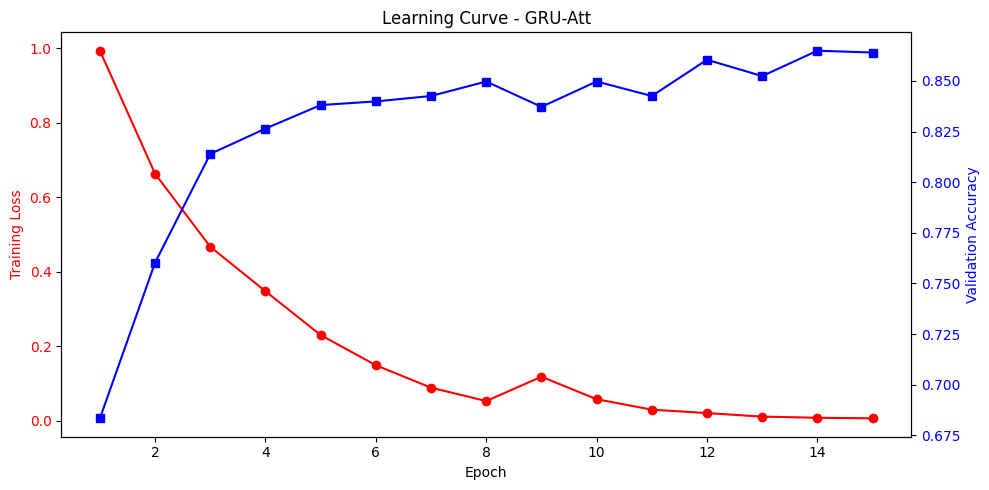

In [ ]:
def plot_learning_curve(history, model_name):
    epochs = range(1, len(history['train_loss'])+1)
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Training Loss', color='red')
    ax1.plot(epochs, history['train_loss'], color='red', marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor='red')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Accuracy', color='blue')
    ax2.plot(epochs, history['val_acc'], color='blue', marker='s', label='Val Acc')
    ax2.tick_params(axis='y', labelcolor='blue')
    plt.title(f'Learning Curve - {model_name}'); fig.tight_layout()
    plt.savefig(f'results/learning_curve_{model_name}.png'); plt.show()

plot_learning_curve(hist_lstm_att, "LSTM+Att"); plot_learning_curve(hist_gru_att, "GRU+Att")
plot_learning_curve(hist_lstm_no, "LSTM-Att"); plot_learning_curve(hist_gru_no, "GRU-Att")

# **Confidence Histogram**

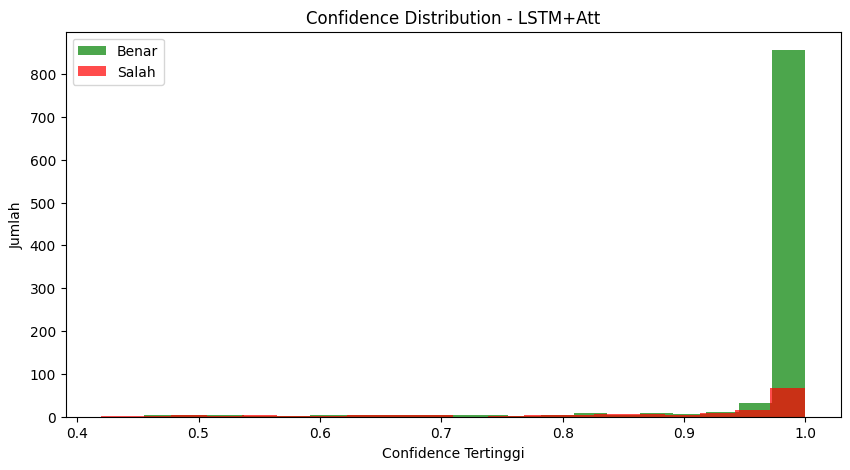

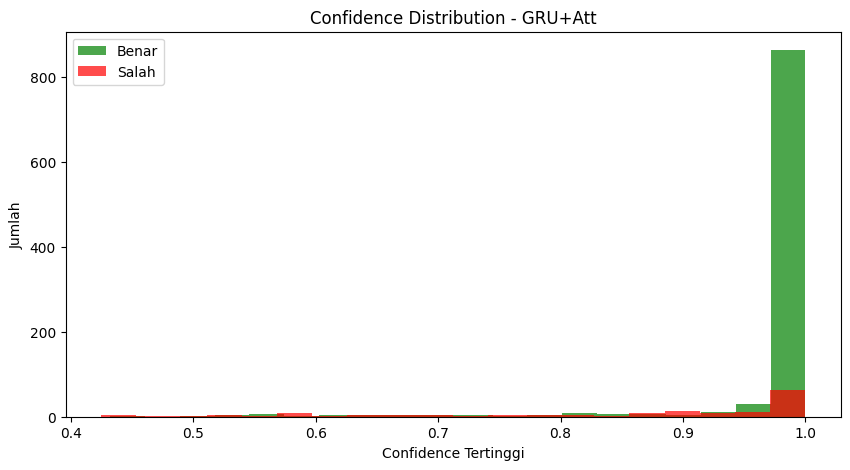

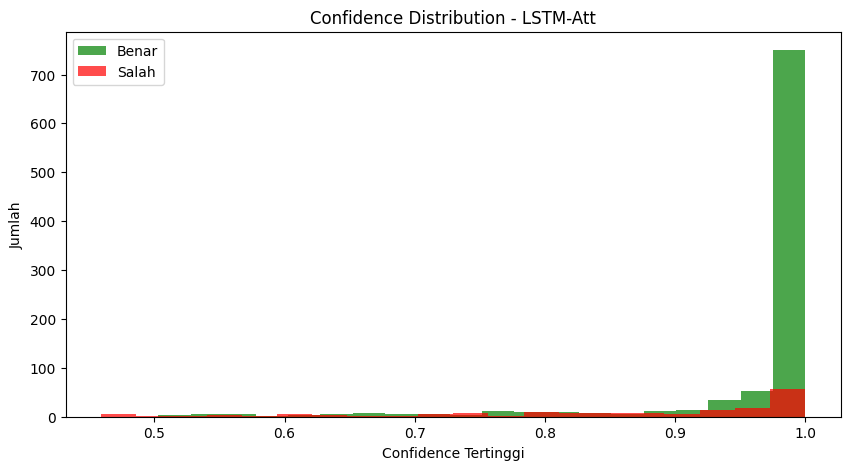

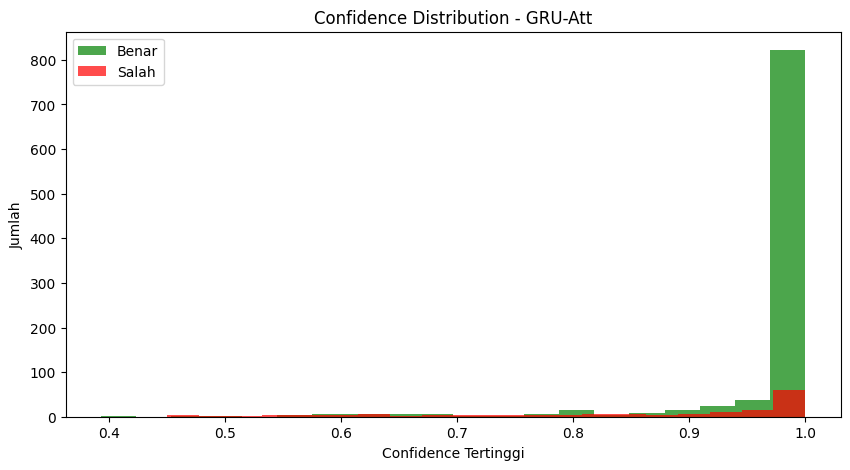

In [ ]:
def confidence_analysis(model, test_loader, name):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            all_probs.append(probs); all_preds.append(preds); all_labels.append(labels.numpy())
    all_probs = np.vstack(all_probs); all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    max_probs = np.max(all_probs, axis=1)
    correct = (all_preds == all_labels)
    plt.figure(figsize=(10,5))
    plt.hist(max_probs[correct], bins=20, alpha=0.7, label='Benar', color='green')
    plt.hist(max_probs[~correct], bins=20, alpha=0.7, label='Salah', color='red')
    plt.xlabel("Confidence Tertinggi"); plt.ylabel("Jumlah")
    plt.title(f"Confidence Distribution - {name}"); plt.legend()
    plt.savefig(f"results/conf_{name}.png"); plt.show()

confidence_analysis(model_lstm_att, test_loader, "LSTM+Att")
confidence_analysis(model_gru_att, test_loader, "GRU+Att")
confidence_analysis(model_lstm_noatt, test_loader, "LSTM-Att")
confidence_analysis(model_gru_noatt, test_loader, "GRU-Att")

# **Visualisasi Attention**

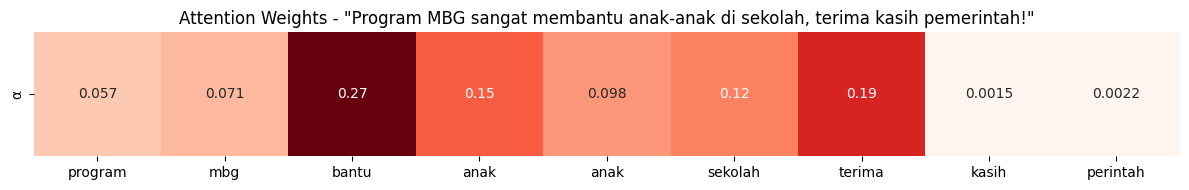

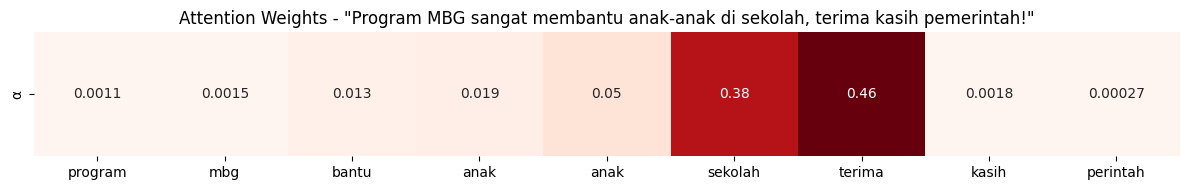

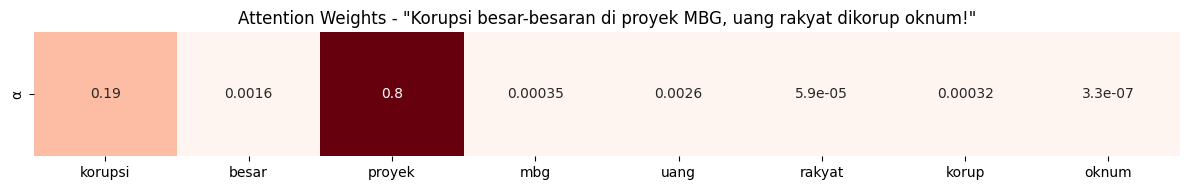

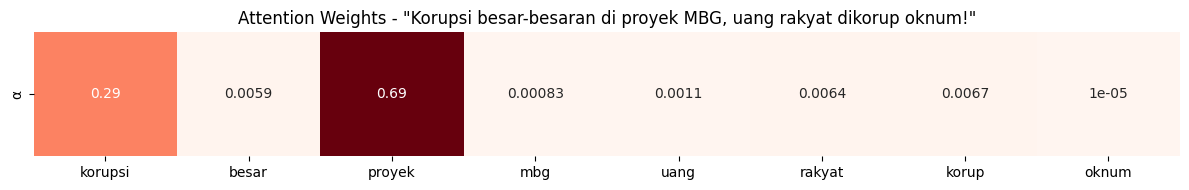

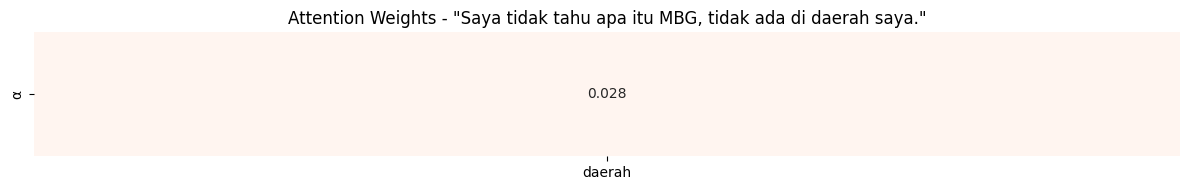

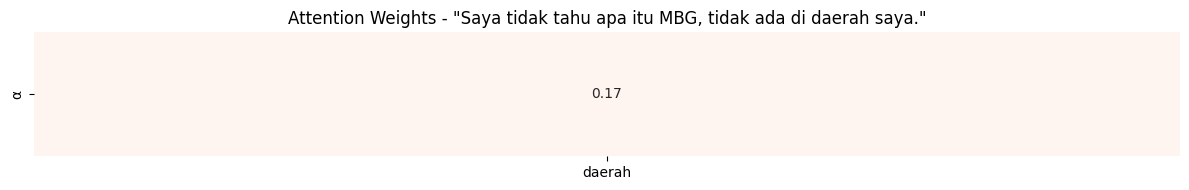

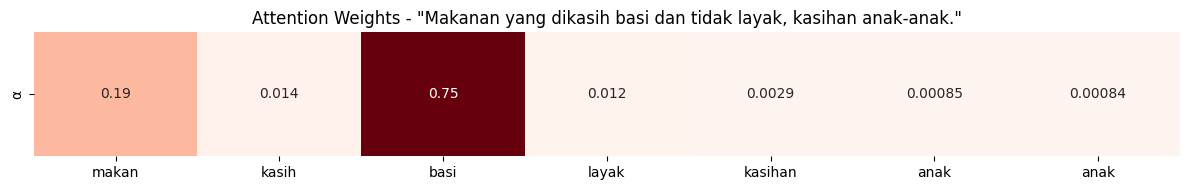

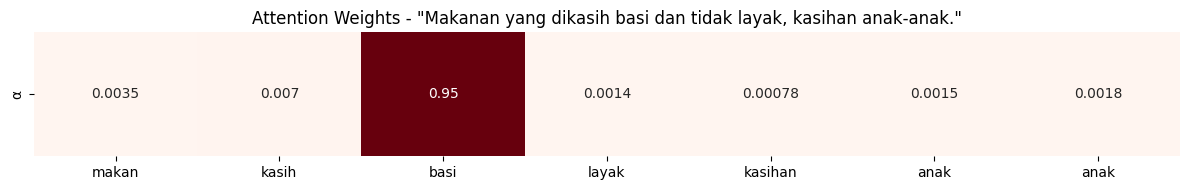

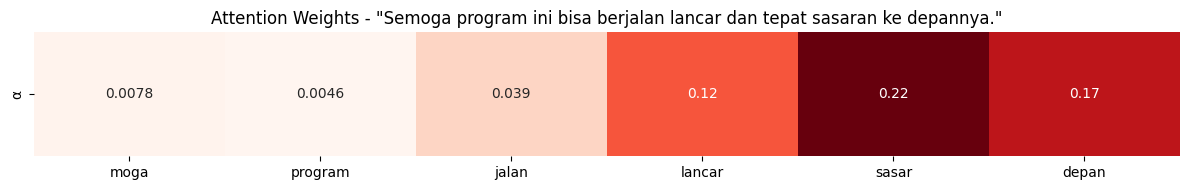

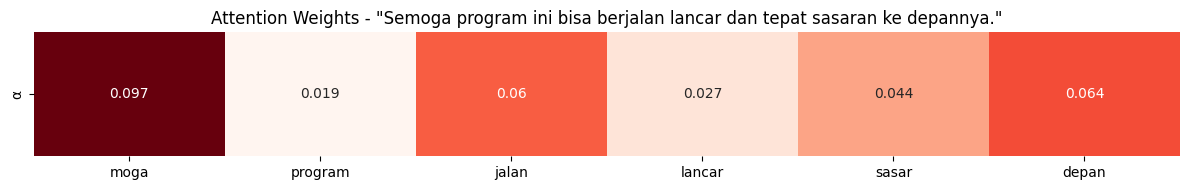

In [ ]:
def visualize_attention(model, text, vocab, max_len=60):
    model.eval()
    cleaned = clean_text(text)
    tokens = cleaned.split()[:max_len]
    ids = [vocab.get(t, 1) for t in tokens] + [0]*(max_len-len(tokens))
    inp = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        x = model.embedding(inp)
        if isinstance(model, AttentionLSTM):
            outputs, _ = model.lstm(x)
        else:
            outputs, _ = model.gru(x)
        attn_weights = torch.softmax(model.attention(outputs).squeeze(-1), dim=1).cpu().numpy()[0][:len(tokens)]
    plt.figure(figsize=(12,2))
    sns.heatmap([attn_weights], xticklabels=tokens, yticklabels=['α'], cmap='Reds', annot=True, cbar=False)
    plt.title(f"Attention Weights - \"{text[:100]}\""); plt.tight_layout(); plt.show()

visualize_attention(model_lstm_att, "Program MBG sangat membantu anak-anak di sekolah, terima kasih pemerintah!", vocab)
visualize_attention(model_gru_att, "Program MBG sangat membantu anak-anak di sekolah, terima kasih pemerintah!", vocab)

visualize_attention(model_lstm_att, "Korupsi besar-besaran di proyek MBG, uang rakyat dikorup oknum!", vocab)
visualize_attention(model_gru_att, "Korupsi besar-besaran di proyek MBG, uang rakyat dikorup oknum!", vocab)

visualize_attention(model_lstm_att, "Saya tidak tahu apa itu MBG, tidak ada di daerah saya.", vocab)
visualize_attention(model_gru_att, "Saya tidak tahu apa itu MBG, tidak ada di daerah saya.", vocab)

visualize_attention(model_lstm_att, "Makanan yang dikasih basi dan tidak layak, kasihan anak-anak.", vocab)
visualize_attention(model_gru_att, "Makanan yang dikasih basi dan tidak layak, kasihan anak-anak.", vocab)

visualize_attention(model_lstm_att, "Semoga program ini bisa berjalan lancar dan tepat sasaran ke depannya.", vocab)
visualize_attention(model_gru_att, "Semoga program ini bisa berjalan lancar dan tepat sasaran ke depannya.", vocab)

# **Evaluasi LSTM dan GRU**


=== LSTM_ATT ===
Acc: 0.8784 | Prec: 0.8777 | Rec: 0.8784 | F1: 0.8779
              precision    recall  f1-score   support

     Neutral       0.88      0.87      0.88       455
    Positive       0.78      0.76      0.77       168
    Negative       0.90      0.92      0.91       495

    accuracy                           0.88      1118
   macro avg       0.86      0.85      0.85      1118
weighted avg       0.88      0.88      0.88      1118



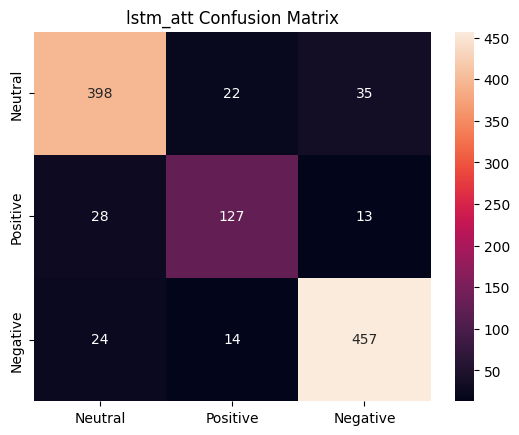


=== GRU_ATT ===
Acc: 0.8739 | Prec: 0.8733 | Rec: 0.8739 | F1: 0.8733
              precision    recall  f1-score   support

     Neutral       0.89      0.87      0.88       455
    Positive       0.76      0.74      0.75       168
    Negative       0.89      0.93      0.91       495

    accuracy                           0.87      1118
   macro avg       0.85      0.84      0.85      1118
weighted avg       0.87      0.87      0.87      1118



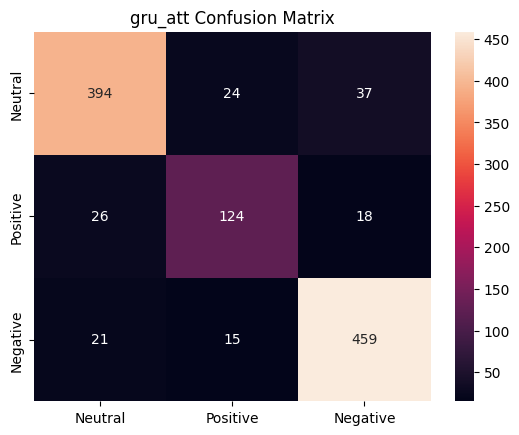


=== LSTM_NOATT ===
Acc: 0.8533 | Prec: 0.8543 | Rec: 0.8533 | F1: 0.8538
              precision    recall  f1-score   support

     Neutral       0.86      0.86      0.86       455
    Positive       0.70      0.73      0.71       168
    Negative       0.90      0.89      0.89       495

    accuracy                           0.85      1118
   macro avg       0.82      0.83      0.82      1118
weighted avg       0.85      0.85      0.85      1118



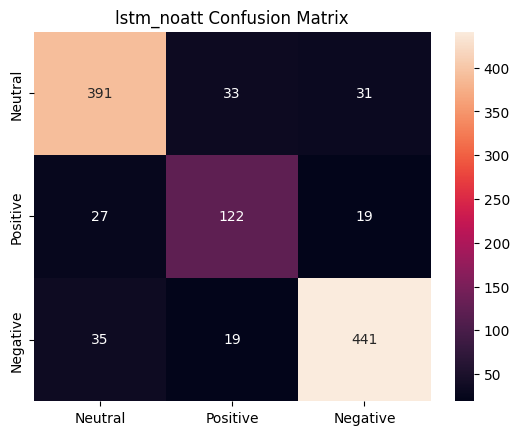


=== GRU_NOATT ===
Acc: 0.8649 | Prec: 0.8636 | Rec: 0.8649 | F1: 0.8641
              precision    recall  f1-score   support

     Neutral       0.86      0.87      0.86       455
    Positive       0.75      0.70      0.72       168
    Negative       0.90      0.92      0.91       495

    accuracy                           0.86      1118
   macro avg       0.84      0.83      0.83      1118
weighted avg       0.86      0.86      0.86      1118



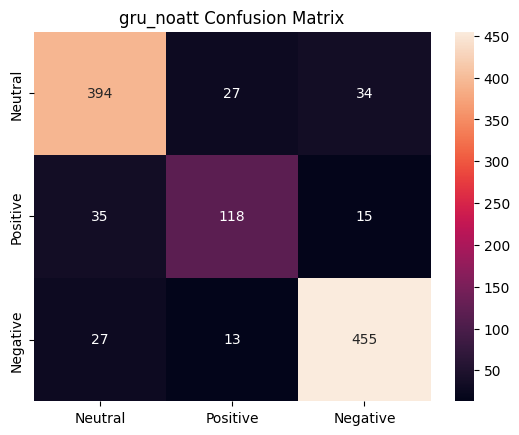

In [ ]:
# Evaluasi
acc_lstm_att, prec_lstm_att, rec_lstm_att, f1_lstm_att, _, _ = evaluate_rnn(model_lstm_att, test_loader, "lstm_att")
acc_gru_att, prec_gru_att, rec_gru_att, f1_gru_att, _, _ = evaluate_rnn(model_gru_att, test_loader, "gru_att")
acc_lstm_no, prec_lstm_no, rec_lstm_no, f1_lstm_no, _, _ = evaluate_rnn(model_lstm_noatt, test_loader, "lstm_noatt")
acc_gru_no, prec_gru_no, rec_gru_no, f1_gru_no, _, _ = evaluate_rnn(model_gru_noatt, test_loader, "gru_noatt")

# **Fine‑tuning IndoBERT untuk Klasifikasi Sentimen**

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")

def tokenize_fn(examples): return tokenizer(examples['bert_text'], padding='max_length', truncation=True, max_length=128)

train_hf = HfDataset.from_pandas(df_train[['bert_text','label']]); test_hf = HfDataset.from_pandas(df_test[['bert_text','label']])
train_hf = train_hf.map(tokenize_fn, batched=True); test_hf = test_hf.map(tokenize_fn, batched=True)
train_hf = train_hf.rename_column('label','labels'); test_hf = test_hf.rename_column('label','labels')
train_hf.set_format('torch', columns=['input_ids','attention_mask','labels']); test_hf.set_format('torch', columns=['input_ids','attention_mask','labels'])

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4468 [00:00<?, ? examples/s]

Map:   0%|          | 0/1118 [00:00<?, ? examples/s]

# **Trainer IndoBERT dengan Early Stopping**

In [ ]:
model_bert = AutoModelForSequenceClassification.from_pretrained("indolem/indobert-base-uncased", num_labels=3).to(device)

training_args = TrainingArguments(
    output_dir="./models/indobert_model", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=64, num_train_epochs=5,
    weight_decay=0.01, logging_dir="./logs/indobert", logging_steps=10,
    load_best_model_at_end=True, metric_for_best_model="accuracy"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred; preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='weighted')}

trainer = Trainer(model=model_bert, args=training_args, train_dataset=train_hf, eval_dataset=test_hf,
                  compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])

start_bert = time.time(); trainer.train(); t_bert = time.time() - start_bert

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.818332,0.716553,0.697674,0.695256
2,0.386086,0.406859,0.831843,0.831082
3,0.281168,0.285192,0.902504,0.903455
4,0.198143,0.263093,0.916816,0.917068
5,0.111455,0.264309,0.917710,0.918025


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

# **Evaluasi IndoBERT & Simpan Model**

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== INDOBERT ===
Acc: 0.9177 | Prec: 0.9186 | Rec: 0.9177 | F1: 0.9180
              precision    recall  f1-score   support

     Neutral       0.92      0.91      0.92       455
    Positive       0.83      0.88      0.85       168
    Negative       0.94      0.94      0.94       495

    accuracy                           0.92      1118
   macro avg       0.90      0.91      0.90      1118
weighted avg       0.92      0.92      0.92      1118



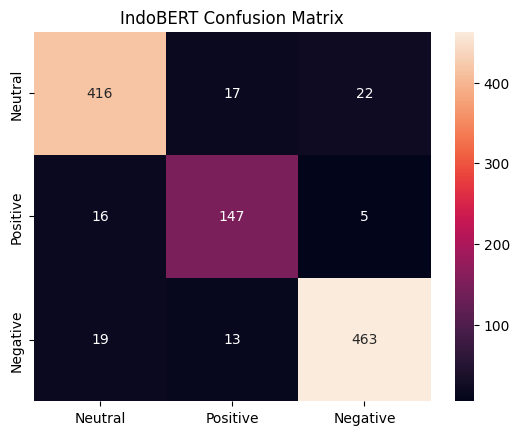

In [ ]:
trainer.save_model("models/indobert_model")

preds = trainer.predict(test_hf)
preds_bert, labels_bert = np.argmax(preds.predictions, axis=-1), preds.label_ids
acc_bert = accuracy_score(labels_bert, preds_bert); prec_bert = precision_score(labels_bert, preds_bert, average='weighted')
rec_bert = recall_score(labels_bert, preds_bert, average='weighted'); f1_bert = f1_score(labels_bert, preds_bert, average='weighted')

print(f"\n=== INDOBERT ===")
print(f"Acc: {acc_bert:.4f} | Prec: {prec_bert:.4f} | Rec: {rec_bert:.4f} | F1: {f1_bert:.4f}")
print(classification_report(labels_bert, preds_bert, target_names=['Neutral','Positive','Negative']))

cm = confusion_matrix(labels_bert, preds_bert)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neutral','Positive','Negative'], yticklabels=['Neutral','Positive','Negative'])
plt.title("IndoBERT Confusion Matrix"); plt.savefig("results/cm_bert.png"); plt.show()

# **Tabel Perbandingan & Simpan Hasil**

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["LSTM + Att", "GRU + Att", "LSTM - Att", "GRU - Att", "IndoBERT"],
    "Accuracy": [acc_lstm_att, acc_gru_att, acc_lstm_no, acc_gru_no, acc_bert],
    "Precision": [prec_lstm_att, prec_gru_att, prec_lstm_no, prec_gru_no, prec_bert],
    "Recall": [rec_lstm_att, rec_gru_att, rec_lstm_no, rec_gru_no, rec_bert],
    "F1-Score": [f1_lstm_att, f1_gru_att, f1_lstm_no, f1_gru_no, f1_bert],
    "Time (s)": [t_lstm_att, t_gru_att, t_lstm_no, t_gru_no, t_bert]
})
comparison_df.to_csv("results/comparison.csv", index=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Time (s)
0,LSTM + Att,0.878354,0.877700,0.878354,0.877949,17.150995
1,GRU + Att,0.873882,0.873296,0.873882,0.873333,12.261805
2,LSTM - Att,0.853309,0.854304,0.853309,0.853766,14.560676
3,GRU - Att,0.864937,0.863577,0.864937,0.864122,11.053235
4,IndoBERT,0.917710,0.918551,0.917710,0.918025,744.431634


# **Tabel Perbandingan untuk Tugas Kelompok Infografis**

In [ ]:
comparison_df_v2 = pd.DataFrame({
    "Model": ["GRU + Att", "GRU - Att", "IndoBERT"],
    "Accuracy": [acc_gru_att, acc_gru_no, acc_bert],
    "Precision": [prec_gru_att, prec_gru_no, prec_bert],
    "Recall": [rec_gru_att, rec_gru_no, rec_bert],
    "F1-Score": [f1_gru_att, f1_gru_no, f1_bert],
    "Time (s)": [t_gru_att, t_gru_no, t_bert]
})
comparison_df_v2.to_csv("results/comparison_VersiKelompokInfografis.csv", index=False)
comparison_df_v2

,Model,Accuracy,Precision,Recall,F1-Score,Time (s)
0,GRU + Att,0.873882,0.873296,0.873882,0.873333,12.261805
1,GRU - Att,0.864937,0.863577,0.864937,0.864122,11.053235
2,IndoBERT,0.917710,0.918551,0.917710,0.918025,744.431634


# **Visualisasi Perbandingan**

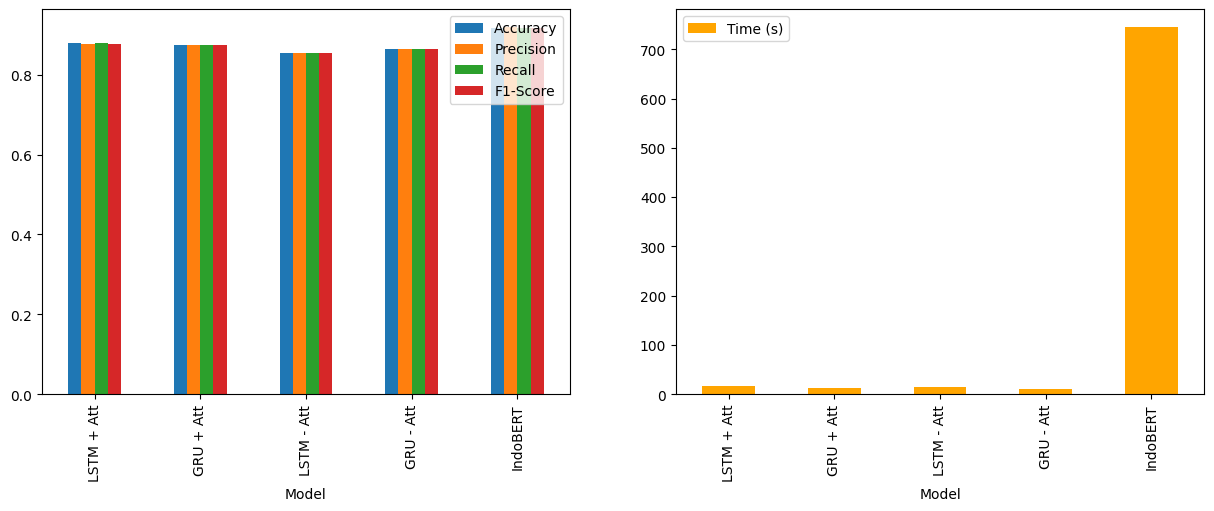

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
comparison_df.plot(x="Model", y=["Accuracy","Precision","Recall","F1-Score"], kind="bar", ax=axes[0])
comparison_df.plot(x="Model", y="Time (s)", kind="bar", color="orange", ax=axes[1])
plt.savefig("results/comparison_plot.png"); plt.show()

# **Visualisasi Perbandingan untuk Tugas Kelompok Infografis**

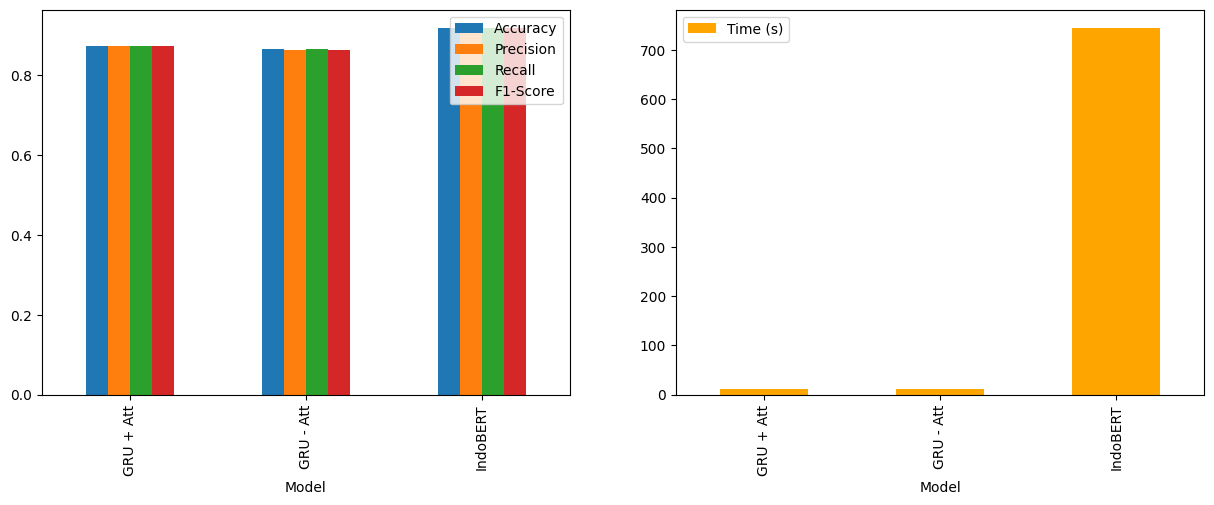

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
comparison_df_v2.plot(x="Model", y=["Accuracy","Precision","Recall","F1-Score"], kind="bar", ax=axes[0])
comparison_df_v2.plot(x="Model", y="Time (s)", kind="bar", color="orange", ax=axes[1])
plt.savefig("results/comparison_plot_v2.png"); plt.show()

# **Inferensi Interaktif**

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Pastikan fungsi clean_text dan vocab sudah ada dari sel sebelumnya
# (clean_text dari Sel 3, vocab dari Sel 9)

def predict_rnn(text, model, vocab):
    cleaned = clean_text(text)
    ids = [vocab.get(t, 1) for t in cleaned.split()[:60]]
    ids += [0] * (60 - len(ids))
    inp = torch.tensor([ids], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        out = model(inp)
        prob = torch.softmax(out, dim=1).cpu().numpy()[0]
        sentimen = ['Netral', 'Positif', 'Negatif'][out.argmax(1).item()]
        return sentimen, prob

def predict_bert_inf(text):
    tok = tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model_bert(**tok)
        prob = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        sentimen = ['Netral', 'Positif', 'Negatif'][out.logits.argmax(1).item()]
        return sentimen, prob

# Widget input
txt = widgets.Textarea(
    placeholder='Ketik komentar...',
    layout=widgets.Layout(width='80%', height='100px')
)
btn = widgets.Button(description='Prediksi Sentimen', button_style='primary')
out = widgets.Output()

def on_click(b):
    if txt.value.strip() == '':
        return
    t = txt.value.strip()

    # Prediksi ketiga model
    s_lstm_att, p_lstm_att = predict_rnn(t, model_lstm_att, vocab)
    s_gru_att,  p_gru_att  = predict_rnn(t, model_gru_att,  vocab)
    s_lstm_noatt, p_lstm_noatt = predict_rnn(t, model_lstm_noatt, vocab)
    s_gru_noatt,  p_gru_noatt  = predict_rnn(t, model_gru_noatt,  vocab)
    s_bert, p_bert = predict_bert_inf(t)

    with out:
        clear_output()
        print(f"📝 Input: \"{t[:200]}\"")
        print("-" * 60)
        print(f"🔵 LSTM + Attention    : {s_lstm_att}")
        print(f"   Prob     : Netral={p_lstm_att[0]:.4f}, Positif={p_lstm_att[1]:.4f}, Negatif={p_lstm_att[2]:.4f}")
        print("")
        print(f"🔴 LSTM    : {s_lstm_noatt}")
        print(f"   Prob     : Netral={p_lstm_noatt[0]:.4f}, Positif={p_lstm_noatt[1]:.4f}, Negatif={p_lstm_noatt[2]:.4f}")
        print("")
        print(f"🟢 GRU + Attention      : {s_gru_att}")
        print(f"   Prob     : Netral={p_gru_att[0]:.4f}, Positif={p_gru_att[1]:.4f}, Negatif={p_gru_att[2]:.4f}")
        print("")
        print(f"🟡 GRU      : {s_gru_noatt}")
        print(f"   Prob     : Netral={p_gru_noatt[0]:.4f}, Positif={p_gru_noatt[1]:.4f}, Negatif={p_gru_noatt[2]:.4f}")
        print("")
        print(f"🟤 IndoBERT : {s_bert}")
        print(f"   Prob     : Netral={p_bert[0]:.4f}, Positif={p_bert[1]:.4f}, Negatif={p_bert[2]:.4f}")
        print("-" * 60)

btn.on_click(on_click)
display(widgets.VBox([txt, btn, out]))

# **Requirements.txt & Download**

In [ ]:
from importlib.metadata import version

libs = ["transformers","datasets","torch","scikit-learn","matplotlib","seaborn","tqdm","pandas","numpy","tensorboard","nltk","wordcloud","Sastrawi","plotly"]
with open("requirements.txt","w") as f:
    for lib in libs:
        try: f.write(f"{lib}=={version(lib)}\n")
        except: pass
!zip -r /content/V4_kode_SentimenAnalisisMBG.zip /content/models /content/results /content/logs /content/requirements.txt

  adding: content/models/ (stored 0%)
  adding: content/models/gru_noatt.pt (deflated 8%)
  adding: content/models/fold_lstm_1.pt (deflated 8%)
  adding: content/models/fold_gru_0.pt (deflated 8%)
  adding: content/models/fold_gru_4.pt (deflated 8%)
  adding: content/models/fold_gru_2.pt (deflated 8%)
  adding: content/models/fold_lstm_2.pt (deflated 8%)
  adding: content/models/fold_lstm_4.pt (deflated 8%)
  adding: content/models/fold_lstm_0.pt (deflated 8%)
  adding: content/models/lstm_noatt.pt (deflated 8%)
  adding: content/models/indobert_model/ (stored 0%)
  adding: content/models/indobert_model/checkpoint-420/ (stored 0%)
  adding: content/models/indobert_model/checkpoint-420/rng_state.pth (deflated 26%)
  adding: content/models/indobert_model/checkpoint-420/scheduler.pt (deflated 61%)
  adding: content/models/indobert_model/checkpoint-420/trainer_state.json (deflated 77%)
  adding: content/models/indobert_model/checkpoint-420/training_args.bin (deflated 53%)
  adding: content

# **Mount Drive dan Simpan**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp V4_kode_SentimenAnalisisMBG.zip /content/drive/MyDrive/

Mounted at /content/drive
